In [137]:
EXP_NAME = "prev10_dim2_cont_SPS"
dataset_path = "synth/prev10_dim2_cont/train"
feature_map = "sps/toy_features_2"

In [138]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import userdata
  from google.colab import drive
  drive.mount('/content/drive')
  PROJECT_ROOT = userdata.get('PROJECT_ROOT')
else:
  PROJECT_ROOT = '../..'
  if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import json
from src.config import Config

sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.2)

sps_audit = pd.read_csv(f'{PROJECT_ROOT}/{Config.RESULTS_DIR}/{EXP_NAME}/sps_audit.csv')
sbs_audit_baseline = pd.read_csv(f'{PROJECT_ROOT}/{Config.RESULTS_DIR}/{EXP_NAME}/sps_audit_baseline.csv')
dataset = pd.read_csv(f'{PROJECT_ROOT}/{Config.DATA_DIR}/{dataset_path}.csv')

with open(f"{PROJECT_ROOT}/configs/{feature_map}.json", 'r') as f:
  features = json.load(f)

# Analysis setup

In [140]:
full_audit = pd.concat([sps_audit, sbs_audit_baseline], ignore_index=True, axis=0)
x_desc_configs = full_audit[full_audit['bucket'] == 'x_desc'].groupby(['iteration'])['feature'].apply(set).to_dict()

iteration_per_feature = full_audit[full_audit['bucket'] == 'x_desc'].groupby('feature')[['iteration']].count()
iteration_per_feature

,iteration
feature,
bio_1,40
bio_2,40
obs_soc_1,40
obs_soc_2,40


In [141]:
# CHANCE LEVEL AUPRC FOR REFERENCE
positives = dataset[dataset[features["target"]["name"]] == 1]
auprc_chance = len(positives) / len(dataset)
subgroups = dataset[features["sens"][0]["name"]].unique().astype(int)

# UTILITY VALUE
full_audit['auprc_value'] = full_audit['u_global_mean_auprc'] - full_audit['abla_global_mean_auprc']

# UTILITY COST
full_audit['auprc_cost'] = full_audit['x_global_mean_auprc'] - full_audit['u_global_mean_auprc']

# CF HARM REDUCTION = CF harm of the original features
full_audit['max_cf_harm_reduction'] = 0
for g in subgroups:
  full_audit['max_cf_harm_reduction'] = full_audit[[f'x_{g}_bal_harm_mean', 'max_cf_harm_reduction']].max(axis=1)



# Config trade-off analysis

In [142]:
tradeoff_audit = full_audit.groupby('iteration')[['max_cf_harm_reduction', 'x_global_mean_auprc', 'auprc_value', 'auprc_cost']].median().round(4)

In [143]:
max_utility_baseline = tradeoff_audit["x_global_mean_auprc"].max()
max_harm_baseline = tradeoff_audit["max_cf_harm_reduction"].max()

# Normalised CF harm reduction: 
# = CF harm reduction / Raw features CF harm
tradeoff_audit['norm_cf_harm_reduction'] = tradeoff_audit['max_cf_harm_reduction'] / max_harm_baseline

# Normalised AUPRC cost:
# = AUPRC cost / Raw features AUPRC
tradeoff_audit['norm_auprc_cost'] = tradeoff_audit['auprc_cost'] / max_utility_baseline

# Normalised AUPRC value:
# = AUPRC Value / Raw features AUPRC
tradeoff_audit['norm_auprc_value'] = tradeoff_audit['auprc_value'] / max_utility_baseline

# Fairness elasticity of Utility
def calc_feu(row):
  return (row['norm_auprc_cost'] / row['norm_cf_harm_reduction']).round(3) if row['norm_cf_harm_reduction'] else "NA"

tradeoff_audit['FEU'] = tradeoff_audit.apply(calc_feu, axis=1)

In [144]:
tradeoff_audit['on_frontier'] = True

for i, current in tradeoff_audit.iterrows():
  for j, other in tradeoff_audit.iterrows():
    if (
      other['norm_auprc_value'] >= current['norm_auprc_value'] and 
      other['norm_auprc_cost'] <= current['norm_auprc_cost'] and 
      other['norm_cf_harm_reduction'] >= current['norm_cf_harm_reduction'] and 
      (
        other['norm_auprc_value'] > current['norm_auprc_value'] or 
        other['norm_auprc_cost'] < current['norm_auprc_cost'] or 
        other['norm_cf_harm_reduction'] > current['norm_cf_harm_reduction']
      )
    ):
      tradeoff_audit.loc[i, 'on_frontier'] = False
      break

pareto_frontier_3d = tradeoff_audit[tradeoff_audit['on_frontier']]
dominated_configs = tradeoff_audit[~tradeoff_audit['on_frontier']]

print("--- 3D Pareto Optimal Configurations ---")
for idx, row in pareto_frontier_3d.iterrows():
  print(f'Iteration {idx}, Xdesc: {x_desc_configs.get(idx, "empty")}')

print("\n")
print(pareto_frontier_3d.drop(['x_global_mean_auprc', 'on_frontier'], axis=1).to_markdown())


--- 3D Pareto Optimal Configurations ---
Iteration 0, Xdesc: {'obs_soc_2', 'bio_2'}
Iteration 11, Xdesc: {'obs_soc_2'}
Iteration 4, Xdesc: {'obs_soc_2', 'obs_soc_1', 'bio_2'}
Iteration INVERTED SCM, Xdesc: {'bio_1', 'bio_2'}
Iteration ORIGINAL SCM, Xdesc: {'obs_soc_2', 'obs_soc_1'}


| iteration    |   max_cf_harm_reduction |   auprc_value |   auprc_cost |   norm_cf_harm_reduction |   norm_auprc_cost |   norm_auprc_value |   FEU |
|:-------------|------------------------:|--------------:|-------------:|-------------------------:|------------------:|-------------------:|------:|
| 0            |                  0.025  |        0.0152 |       0.0026 |                 0.393701 |        0.00877489 |          0.0512994 | 0.022 |
| 11           |                  0.0115 |        0.0064 |       0.0024 |                 0.181102 |        0.0080999  |          0.0215997 | 0.045 |
| 4            |                  0.0375 |        0.0045 |       0.0155 |                 0.590551 |        0.05231

## Visualisation

### 3D frontier

In [145]:
tradeoff_3d = tradeoff_audit.reset_index(names="iteration")
tradeoff_3d['status'] = tradeoff_3d['on_frontier'].map({True: '3D Pareto Frontier', False: 'Dominated Config'})

min_auprc_val = min(tradeoff_3d['norm_auprc_value'].min(), tradeoff_3d['norm_auprc_cost'].min())
max_auprc_val = max(tradeoff_3d['norm_auprc_value'].max(), tradeoff_3d['norm_auprc_cost'].max())

axis_buffer = (max_val - min_val) * 0.05
unified_range = [min_val - axis_buffer, max_val + axis_buffer]

fig = px.scatter_3d(
    tradeoff_3d, 
    x='norm_auprc_value', 
    y='norm_auprc_cost', 
    z='norm_cf_harm_reduction',
    color='status',
    color_discrete_map={'3D Pareto Frontier': 'red', 'Dominated Config': 'gray'},
    hover_name='iteration',
    title='Interactive 3D VAE Trade-Off Exploration'
)

# Adjust marker sizes (make the frontier triangles pop)
fig.update_traces(marker=dict(size=6, line=dict(width=1, color='DarkSlateGrey')))

fig.update_layout(
    # Fix truncation by wiping out external margins and maximizing width/height
    width=1000,
    height=800,
    margin=dict(l=0, r=0, b=0, t=50), 
    
    # Scene configuration
    scene=dict(
        # Bind utility and cost to the exact same visual coordinate scale limits
        xaxis=dict(
            title='AUPRC Value (Maximise)', 
            range=unified_range,
            backgroundcolor="rgb(243, 243, 243)",
            gridcolor="white",
            showbackground=True,
            zerolinecolor="gray",
        ),
        yaxis=dict(
            title='AUPRC Cost (Minimise)', 
            range=unified_range,
            backgroundcolor="rgb(243, 243, 243)",
            gridcolor="white",
            showbackground=True,
            zerolinecolor="gray",
        ),
        zaxis=dict(
            title='Counterfactual Harm Reduction (Maximise)',
            backgroundcolor="rgb(230, 235, 245)",
            gridcolor="white",
            showbackground=True,
            zerolinecolor="gray",
        ),
        # Default rotation angle to see the cost vs value floor clearly
        camera=dict(
            eye=dict(x=1.6, y=1.6, z=1.2)
        )
    ),
    legend=dict(
        yanchor="top",
        y=0.95,
        xanchor="left",
        x=0.05
    )
)

fig.show()

### 2D frontiers

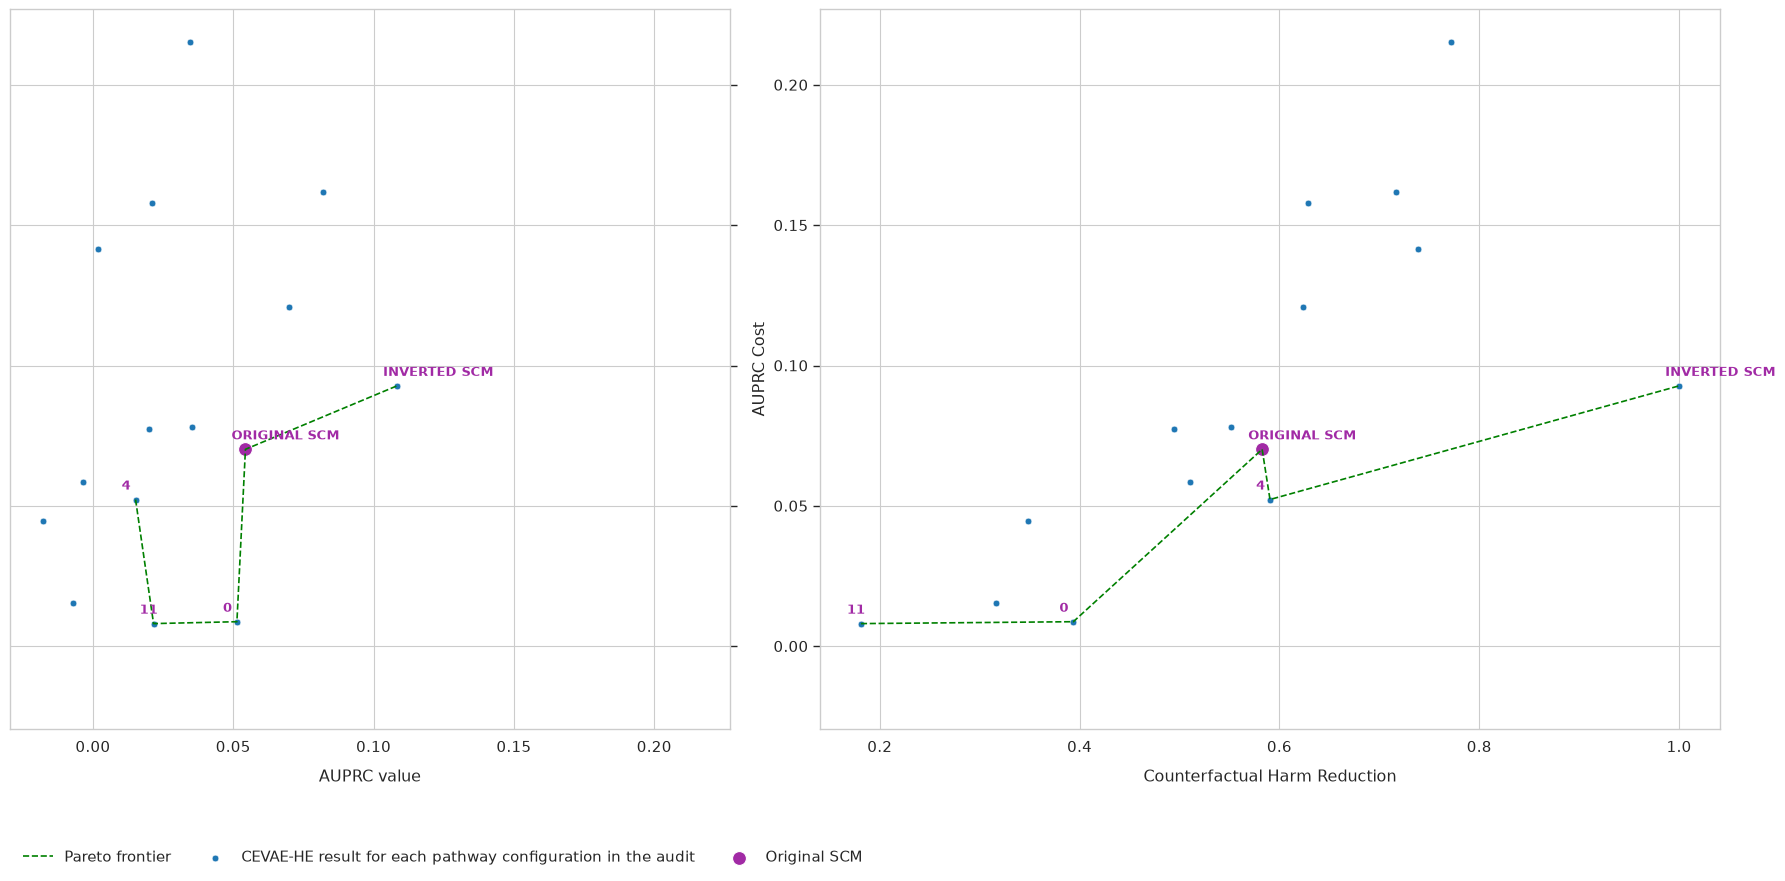

In [158]:
fig = plt.figure(figsize=(18, 9))

ax1 = fig.add_subplot([0, 0, 0.4, 0.8])
ax2 = fig.add_subplot([0.45, 0, 0.5, 0.8], sharey=ax1)

# AUPRC Cost vs AUPRC Cost
sns.lineplot(data=pareto_frontier_3d, x='norm_auprc_value', y='norm_auprc_cost', color="green", marker='', linestyle="--", errorbar=None, ax=ax1)
sns.scatterplot(data=tradeoff_audit, x='norm_auprc_value', y='norm_auprc_cost', ax=ax1)
# OPTIONAL: identify the original SCM
sns.scatterplot(data=tradeoff_audit.loc[['ORIGINAL SCM']], color='#a12aa5', s=100, x='norm_auprc_value', y='norm_auprc_cost', ax=ax1)

# AUPRC Cost vs Max Subgroup CF harm reduction
sns.lineplot(data=pareto_frontier_3d, x='norm_cf_harm_reduction', y='norm_auprc_cost', color="green", marker='', linestyle="--", errorbar=None, ax=ax2)
sns.scatterplot(data=tradeoff_audit, x='norm_cf_harm_reduction', y='norm_auprc_cost', ax=ax2)
# OPTIONAL: identify the original SCM
sns.scatterplot(data=tradeoff_audit.loc[['ORIGINAL SCM']], color='#a12aa5', s=100, x='norm_cf_harm_reduction', y='norm_auprc_cost', ax=ax2)

for idx, row in pareto_frontier_3d.iterrows():
  ax1.annotate(
    str(idx),                      
    (row['norm_auprc_value'], row['norm_auprc_cost']), 
    textcoords="offset points",    
    xytext=(-10, 5),                 
    ha='left',
    va='bottom',  
    fontsize=9, 
    fontweight='bold', 
    color='#a12aa5'
    )
  ax2.annotate(
    str(idx),                      
    (row['norm_cf_harm_reduction'], row['norm_auprc_cost']), 
    textcoords="offset points",    
    xytext=(-10, 5),                 
    ha='left',
    va='bottom',  
    fontsize=9, 
    fontweight='bold', 
    color='#a12aa5'
    )

ax1.set_xlim(unified_range)
ax1.set_ylim(unified_range)
ax1.set_aspect("equal", adjustable='box')

ax1.tick_params(axis='y', which='both', right=True, labelright=False, left=False, labelleft=False)
ax1.set_xlabel('AUPRC value', labelpad=10)
ax1.set_ylabel('')

ax2.set_ylabel('AUPRC Cost')
ax2.tick_params(axis='y', which='both', right=False, labelright=False, left=True, labelleft=True)
ax2.set_xlabel('Counterfactual Harm Reduction', labelpad=10)

ax1.legend(labels=[ 
                   'Pareto frontier', 
                   'CEVAE-HE result for each pathway configuration in the audit',
                   'Original SCM'
                   ],
           loc='upper left', bbox_to_anchor=(0, -.15), edgecolor="white", ncol=3)

plt.show()


# All configs

In [159]:
def find_config(row):
  return x_desc_configs.get(row['id'], "empty Xdesc")

all_configs = tradeoff_3d.sort_values('norm_auprc_value', ascending=False).reset_index(names="id")
all_configs['Xdesc config'] = all_configs.apply(find_config, axis=1)

print(all_configs.drop('x_global_mean_auprc', axis=1).to_markdown(index=False))

|   id | iteration    |   max_cf_harm_reduction |   auprc_value |   auprc_cost |   norm_cf_harm_reduction |   norm_auprc_cost |   norm_auprc_value |   FEU | on_frontier   | status             | Xdesc config   |
|-----:|:-------------|------------------------:|--------------:|-------------:|-------------------------:|------------------:|-------------------:|------:|:--------------|:-------------------|:---------------|
|   13 | INVERTED SCM |                  0.0635 |        0.0321 |       0.0275 |                 1        |        0.0928113  |         0.108336   | 0.093 | True          | 3D Pareto Frontier | empty Xdesc    |
|    0 | -1           |                  0.0455 |        0.0243 |       0.048  |                 0.716535 |        0.161998   |         0.0820115  | 0.226 | False         | Dominated Config   | empty Xdesc    |
|    2 | 1            |                  0.0396 |        0.0207 |       0.0358 |                 0.623622 |        0.120823   |         0.0698616  | 0.194 |